In [1]:
# Import libraries
import numpy as np
import math
import pandas as pd
import os
# Import graphing libraries
import matplotlib.pyplot as plt
import seaborn as sns  # Theme
import pickle
from matplotlib.dates import DayLocator, MonthLocator, DateFormatter

In [2]:
# Import dataset
dataset = pd.read_csv("../data/mag7_stocks.csv")

# Check if data is loaded
print(dataset.head(), "\n")
dataset.info()

# Convert date datatype from object to datetime
dataset[dataset.columns[1]] = pd.to_datetime(dataset[dataset.columns[1]])
# dataset = dataset[dataset["Date"] < "2025-09-01"]
# dataset = dataset[dataset['Date'] < '2025-10-01']
dataset.info()

   Unnamed: 0        date    open     high     low   close    volume  Name
0           0  2023-01-04  102.61  105.368  102.00  105.35  67649387  AAPL
1           1  2023-01-05  105.75  105.850  102.41  102.71  55790992  AAPL
2           2  2023-01-06  100.56  102.370   99.87  100.70  68457388  AAPL
3           3  2023-01-07   98.68  100.130   96.43   96.45  81094428  AAPL
4           4  2023-01-08   98.55   99.110   96.76   96.96  70798016  AAPL 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2645 entries, 0 to 2644
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2645 non-null   int64  
 1   date        2645 non-null   object 
 2   open        2645 non-null   float64
 3   high        2645 non-null   float64
 4   low         2645 non-null   float64
 5   close       2645 non-null   float64
 6   volume      2645 non-null   int64  
 7   Name        2645 non-null   object 
dtypes: float64(4), int64(2), ob

In [3]:
# Folder to place our matplotlib figures in
figures_folder_name = "figures"

In [4]:
# Show companies
companies = dataset["Name"].dropna().unique().tolist()
print(companies)

['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'NVDA']


In [23]:
# Identify column names from dataset
COL_DATE = "date"
COL_NAME = "Name"
COL_OPEN = "open"
COL_HIGH = "high"
COL_LOW = "low"
COL_CLOSE = "close"
COL_VOLUME = "volume"

In [24]:
# Theme of graphs
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.frameon": True,
    "legend.framealpha": 1,
})

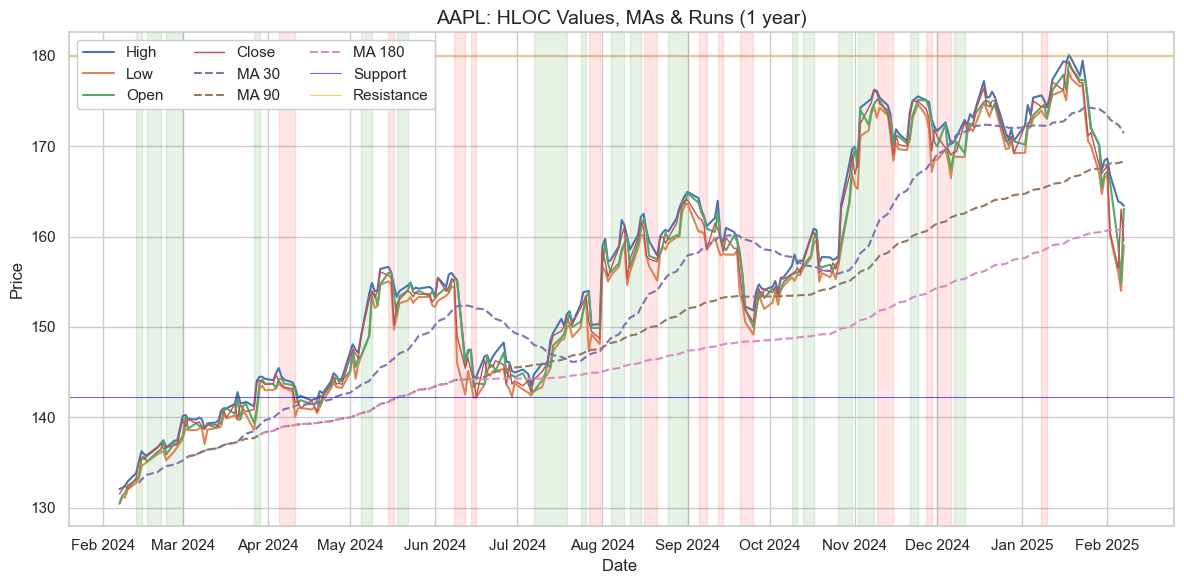

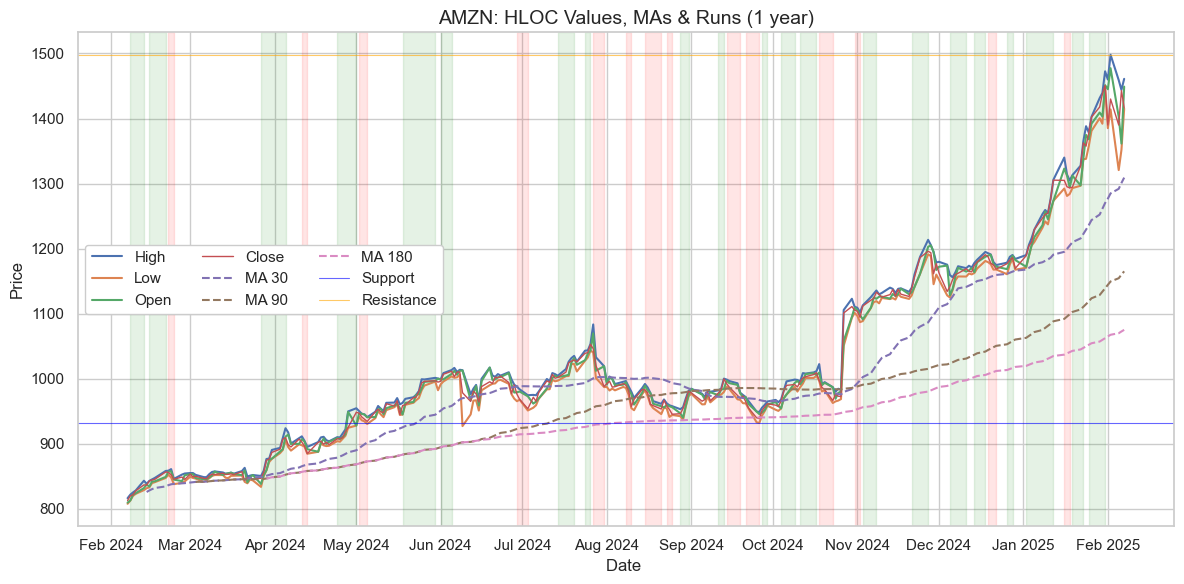

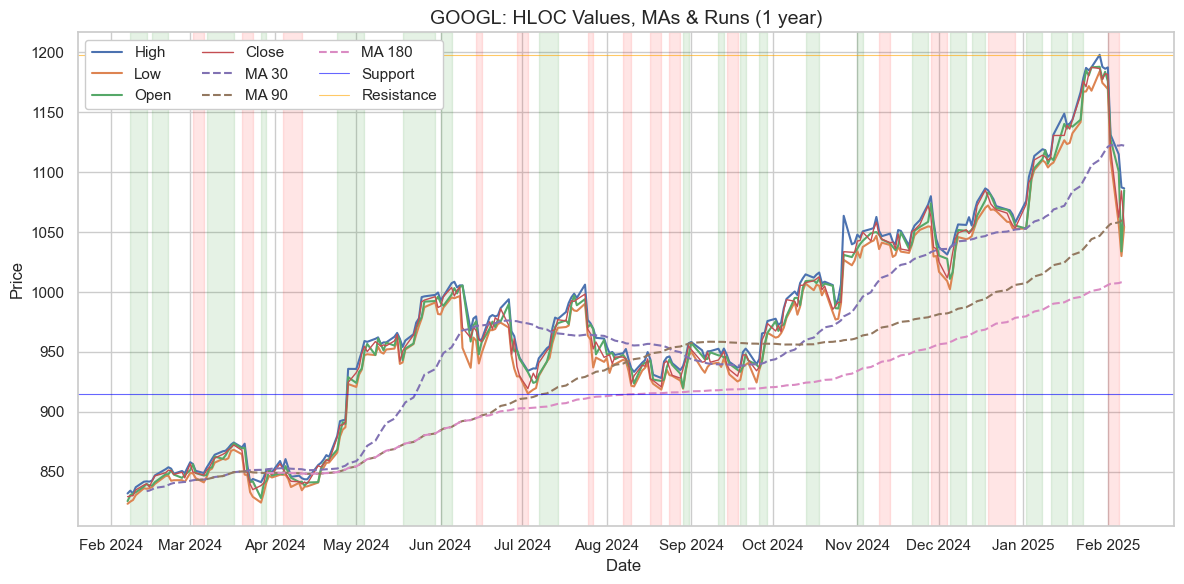

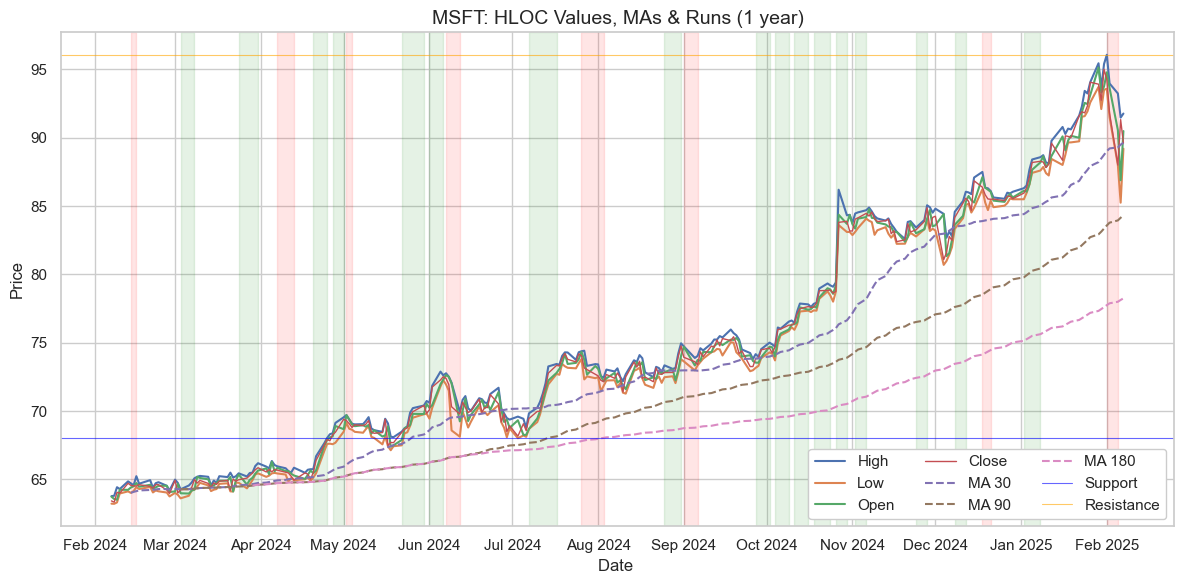

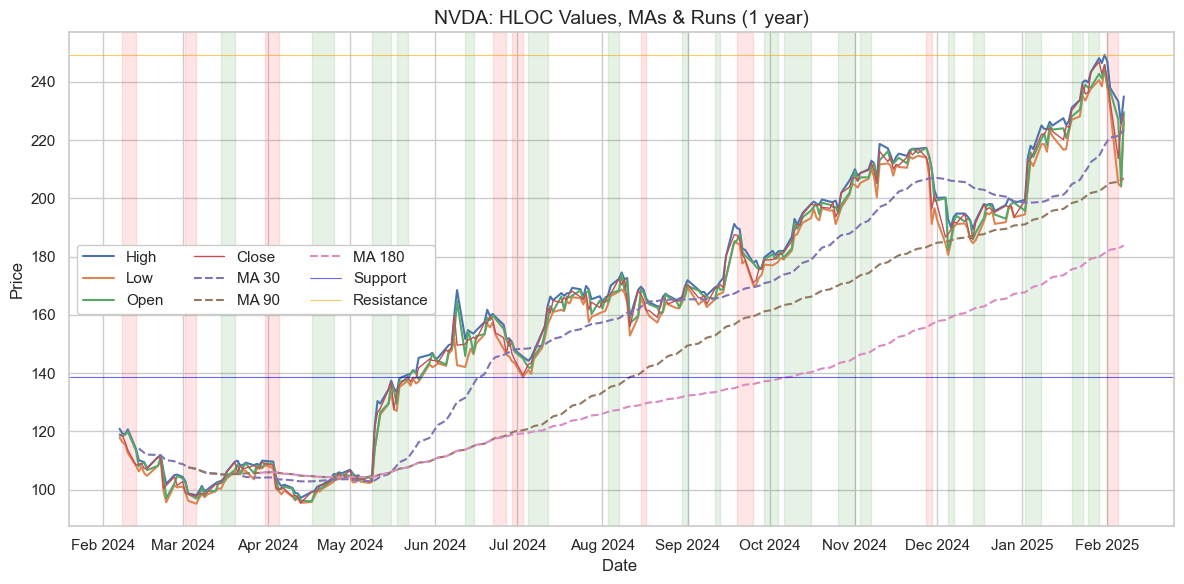

In [26]:
for name in companies:

    # Split company data from dataset
    df = dataset[dataset[COL_NAME] == name]
    df = df.sort_values(by=COL_DATE)

    # Select recency of data
    recency_type = "years" # Select days, months, or years
    recency_value = 1
    last_date = df[COL_DATE].max()

    if recency_type == "years":
        start_date = last_date - pd.DateOffset(years=recency_value)
    elif recency_type == "months":
        start_date = last_date - pd.DateOffset(months=recency_value)
    else:
        start_date = last_date - pd.DateOffset(days=recency_value)

    df = df[df[COL_DATE] >= start_date]

    # Calculate and append Moving Averages
    for win in (30, 90, 180): # 1,3,6 Months
        df[f"MA_{win}"] = df[COL_CLOSE].rolling(window=win, min_periods=max(5, win//5)).mean()

    # Calculate upward/downward runs based on diff. in closing prices of each day and the day before. Each day is labelled as 'up'(1)/'down'(-1)/'no change'(0)
    # and consecutive runs (at least 3d) are grouped.
    df["Close_Diff"] = df[COL_CLOSE].diff()
    df["Run"] = df["Close_Diff"].apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))
    df["Run_Group"] = (df["Run"] != df["Run"].shift()).cumsum()
    run_segments = df.groupby("Run_Group").filter(lambda x: len(x) >= 3)

    # Dynamic support/resistance window based on timeframe (days,months,year) - Better captures short-term volatility and long-term stability, more accurate S&R
    if recency_type == "days":
        sr_window = 5
    elif recency_type == "months":
        sr_window = 20
    else:  # years
        sr_window = 60

    # Calculate support and resistance
    support = df[COL_LOW].rolling(window=sr_window, min_periods=1).min()
    resistance = df[COL_HIGH].rolling(window=sr_window, min_periods=1).max()

    # Pick key recent levels
    support_levels = support.tail(100).nsmallest(3).unique()
    resistance_levels = resistance.tail(100).nlargest(3).unique()

    # Plot and label values
    fig, ax = plt.subplots()
    ax.plot(df[COL_DATE], df[COL_HIGH], label="High")
    ax.plot(df[COL_DATE], df[COL_LOW], label="Low")
    ax.plot(df[COL_DATE], df[COL_OPEN], label="Open")
    ax.plot(df[COL_DATE], df[COL_CLOSE], label="Close", linewidth=1)

    # Plot and label Moving Averages
    for win in (30, 90, 180):
        ax.plot(df[COL_DATE], df[f"MA_{win}"] , label=f"MA {win}", linestyle="--")

    #Plot support and resistance levels
    for level in support_levels:
        ax.axhline(y=level, color='blue', linestyle='-', linewidth=0.8, alpha=0.6,
                  label="Support" if "Support" not in ax.get_legend_handles_labels()[1] else "")

    for level in resistance_levels:
        ax.axhline(y=level, color='orange', linestyle='-', linewidth=0.8, alpha=0.6,
                  label="Resistance" if "Resistance" not in ax.get_legend_handles_labels()[1] else "")


    # Highlight upward/downward runs
    for _, group in run_segments.groupby("Run_Group"):
        color = 'green' if group["Run"].iloc[0] == 1 else 'red'
        ax.axvspan(group[COL_DATE].iloc[0], group[COL_DATE].iloc[-1], color=color, alpha=0.1)

    # Show every day on x-axis if within a month
    if (recency_type == "days" and recency_value <= 31) or (
        recency_type == "months" and recency_value == 1):
        ax.xaxis.set_major_locator(DayLocator(interval=1))
        ax.xaxis.set_major_formatter(DateFormatter('%d'))

    # Show every month on x-axis if within a year
    elif recency_type == "years" and recency_value == 1:
        ax.xaxis.set_major_locator(MonthLocator())
        ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))

    # Label graph and axis
    ax.set_title(f"{name}: HLOC Values, MAs & Runs ({recency_value} {recency_type[0:-1] if recency_value == 1 else recency_type})")
    ax.set_xlabel(f"Date {'(day)' if recency_type == 'days' or recency_type == 'months' and recency_value == 1 else ''}")
    ax.set_ylabel("Price")
    ax.legend(ncol=3)
    plt.tight_layout()
    plt.show()
    print("\n")


    file_path = os.path.join(figures_folder_name, name)
    with open(file_path, 'wb') as f:
        pickle.dump(fig, f)

    print("\n")

In [93]:
from pathlib import Path


with open(Path.cwd().parent / "graphs" /  "figures" / "AAPL", "rb") as f:
    fig = pickle.load(f)

fig.axes[0].lines

<Axes.ArtistList of 10 lines>

In [53]:
fig.axes[0].lines

<Axes.ArtistList of 10 lines>